In [1]:
import pybamm as pb
import matplotlib.pyplot as plt
import numpy as np

c:\ProgramData\anaconda3\Lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been deprecated and will be removed in a future release
  "class": algorithms.Blowfish,


In [2]:
##################################
# generate labels for the graphs #
##################################
temps = list(np.asarray([-10, 0, 10, 20, 30, 40]) + 273)
labels = []
for temp in temps:
    temp -= 273
    labels.append(str(f"{temp}$^o$C"))
print(labels)

# load all the saved solutions 
graphite_VK_1C_5cycles = []
for temp in temps:
    sol = pb.load(f"graphite_VK_{temp}K_1C_5cycles.pkl")
    graphite_VK_1C_5cycles.append(sol)

print(graphite_VK_1C_5cycles)

['-10$^o$C', '0$^o$C', '10$^o$C', '20$^o$C', '30$^o$C', '40$^o$C']
[<pybamm.solvers.solution.Solution object at 0x0000023103C4A2D0>, <pybamm.solvers.solution.Solution object at 0x000002310BDCF230>, <pybamm.solvers.solution.Solution object at 0x000002310BD76AB0>, <pybamm.solvers.solution.Solution object at 0x0000023103B1AFC0>, <pybamm.solvers.solution.Solution object at 0x0000023103B5EF30>, <pybamm.solvers.solution.Solution object at 0x000002310BDCC8F0>]


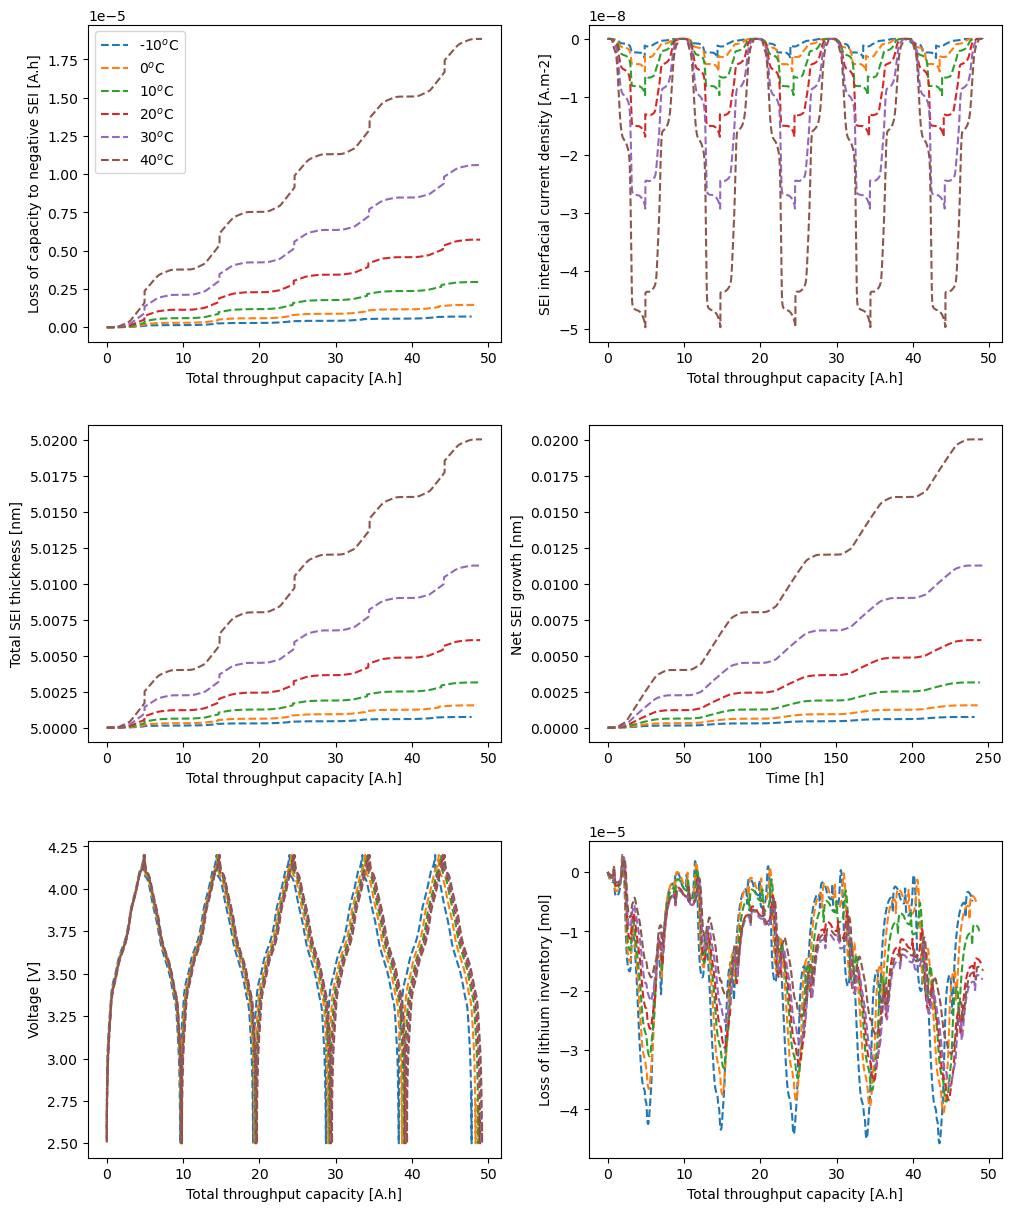

In [17]:
def plot_results(solution_set, variables):
    '''
    plot graph of SEI thickness, Capacity loss and Voltage against total throughput

        solution_set = list of solutions after solving multiple models
        variables = variables changed during parametric sweep
    
    '''

    fig, axes = plt.subplots(3,2, layout="constrained", figsize=(10,12), gridspec_kw={"hspace": 0.1}, sharex=False)
    plt.ticklabel_format(style="sci", axis="y", scilimits=(0,0))

    max_C_dis = []
    for index, sol in enumerate(solution_set):
        # independent variable
        Q_tot = sol["Throughput capacity [A.h]"].entries
        t = sol["Time [h]"].entries

        # various dependent variables
        Q_SEI = sol["Loss of capacity to negative SEI [A.h]"].entries
        J_SEI = sol["X-averaged negative electrode SEI interfacial current density [A.m-2]"].entries
        V_i = sol["Voltage [V]"].entries
        # electrolyte_V = sol["Electrolyte potential [V]"].entries
        C_dis = np.abs(sol["Discharge capacity [A.h]"].entries)
        Q_LLI = sol["Total lithium lost [mol]"].entries# *96485.3 / 3600
        
        L_SEI = (sol["X-averaged negative total SEI thickness [m]"].entries) *1e9
        L_min = np.min(sol["X-averaged negative total SEI thickness [m]"].entries) *1e9
        delta_L = (L_SEI - L_min)


        # plot graph on the go
        axes[0][0].plot(Q_tot, Q_SEI, label=f"{variables[index]}", linestyle="--")
        axes[0][1].plot(Q_tot, J_SEI, label=f"{variables[index]}", linestyle="--")
        axes[1][0].plot(Q_tot, L_SEI, label=f"{variables[index]}", linestyle="--")
        axes[1][1].plot(t, delta_L, label=f"{variables[index]}", linestyle="--")
        axes[2][0].plot(Q_tot, V_i, label=f"{variables[index]}", linestyle="--")
        axes[2][1].plot(Q_tot, Q_LLI, label=f"{variables[index]}", linestyle="--")
        
    # graph formatting
    axes[0][0].set_xlabel("Total throughput capacity [A.h]")
    axes[0][0].set_ylabel("Loss of capacity to negative SEI [A.h]") 
    axes[0][0].legend()
    #axes[0][0].title("")
    
    axes[0][1].set_xlabel("Total throughput capacity [A.h]")
    axes[0][1].set_ylabel("SEI interfacial current density [A.m-2]")

    axes[1][0].set_xlabel("Total throughput capacity [A.h]")
    axes[1][0].set_ylabel("Total SEI thickness [nm]")


    axes[1][1].set_xlabel("Time [h]")
    axes[1][1].set_ylabel("Net SEI growth [nm]")

    axes[2][0].set_xlabel("Total throughput capacity [A.h]")
    axes[2][0].set_ylabel("Voltage [V]")

    axes[2][1].set_xlabel("Total throughput capacity [A.h]")
    axes[2][1].set_ylabel("Loss of lithium inventory [mol]")

plot_results(graphite_VK_1C_5cycles, labels)

SEI growth in cycle 0 of temp 263= [0.0001490552279993834] nm
SEI growth in cycle 1 of temp 263= [0.0001490552279993834, 0.00014905019756831698] nm
SEI growth in cycle 2 of temp 263= [0.0001490552279993834, 0.00014905019756831698, 0.00014905110370083745] nm
SEI growth in cycle 3 of temp 263= [0.0001490552279993834, 0.00014905019756831698, 0.00014905110370083745, 0.00014905652963259733] nm
SEI growth in cycle 4 of temp 263= [0.0001490552279993834, 0.00014905019756831698, 0.00014905110370083745, 0.00014905652963259733, 0.00014905627487089485] nm
average growth per cycle: 0.00014905386675440602 [nm]
Rate of SEI growth: 6.180251536961175e-07 [nm h-1]
SEI growth in cycle 0 of temp 273= [0.00031113075912623053] nm
SEI growth in cycle 1 of temp 273= [0.00031113075912623053, 0.000311142043711917] nm
SEI growth in cycle 2 of temp 273= [0.00031113075912623053, 0.000311142043711917, 0.0003111423750473831] nm
SEI growth in cycle 3 of temp 273= [0.00031113075912623053, 0.000311142043711917, 0.00031

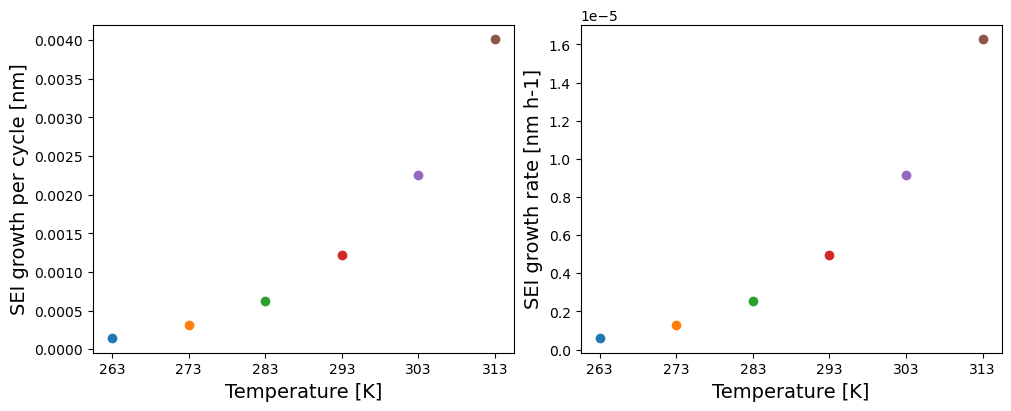

In [15]:
fig, axes = plt.subplots(1, 2, layout="constrained", figsize=(10,4), gridspec_kw={"hspace": 0.1}, sharex=False)
plt.ticklabel_format(style="sci", axis="y", scilimits=(0,0))


for idx, solution in enumerate(graphite_VK_1C_5cycles):
    """
    Iterate through each solution (temperature)
    splits values of each solution into 5
    Calculate change in SEI growth each cycle, at each temperature
    Plots the growth per cycle as a function of temperature
    """
    # extract the data from each solution obj as an array
    sols = solution["X-averaged negative total SEI thickness [m]"].entries
    # splits evenly into 5
    vals = np.array_split(sols, 5)       
    
    d = []
    # iterate through each cycle per solution
    for i, part in enumerate(vals):
        d.append((np.max(part) - np.min(part))*1e9)    # find the change in SEI growth each cycle
        print(f"SEI growth in cycle {i} of temp {temps[idx]}= {d} nm")


    dL = np.average(d)  # average growth across 5 cycles
    print(f"average growth per cycle: {dL} [nm]")

    t = solution["Time [h]"].entries
    dLdt = dL/ (np.max(t))
    print(f"Rate of SEI growth: {dLdt} [nm h-1]")

    # plotting graph on the go
    axes[0].plot(temps[idx], dL, marker="o")    # growth per cycle
    axes[1].plot(temps[idx], dLdt, marker="o")  # growth rate (per h)


# plot formatting

axes[0].set_xticks(temps)
axes[0].set_xlabel("Temperature [K]", fontsize=14)
axes[0].set_ylabel("SEI growth per cycle [nm]", fontsize=14)

axes[1].set_xticks(temps)
axes[1].set_xlabel("Temperature [K]", fontsize=14)
axes[1].set_ylabel("SEI growth rate [nm h-1]", fontsize=14)
plt.show()